# RITMO Pipeline - Validación Completa

**Estados Ocultos como Embeddings Estructurados**

Pipeline:
1. RevIN → Normalización reversible
2. Baum-Welch → Entrenamiento HMM (K=5 tokens)
3. Viterbi → Tokenización
4. Embeddings → e_k = [μ_k, σ_k, A[k,:]]

In [1]:
import os
import sys
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir('..')

print(f'Working directory: {Path.cwd()}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from utils.revin import RevINNormalizer
from hmm import baum_welch, viterbi_decode, save_hmm_params, load_hmm_params
from embeddings import EmbeddingGenerator

# Configuración matplotlib (paper-ready)
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

colors_oi = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

print('Setup completo')

Working directory: /home/jaime/TFG/RITMO
Setup completo


## 1. Carga ETTh1

In [2]:
df = pd.read_csv('dataset/ETT-small/ETTh1.csv')
data = df['OT'].values

data_train = data[:8640]
data_val = data[8640:8640+2880]
data_test = data[8640+2880:]

print('[ETTh1 DATASET]')
print(f'  Train: {len(data_train)} samples')
print(f'  Val:   {len(data_val)} samples')
print(f'  Test:  {len(data_test)} samples')

[ETTh1 DATASET]
  Train: 8640 samples
  Val:   2880 samples
  Test:  5900 samples


## 2. RevIN Normalización

[REVIN NORMALIZACIÓN]
  Pre:  μ=17.128, σ=9.176
  Post: μ=-0.000000, σ=1.000000
  Reversibilidad: MSE=1.07e-13, Success=True


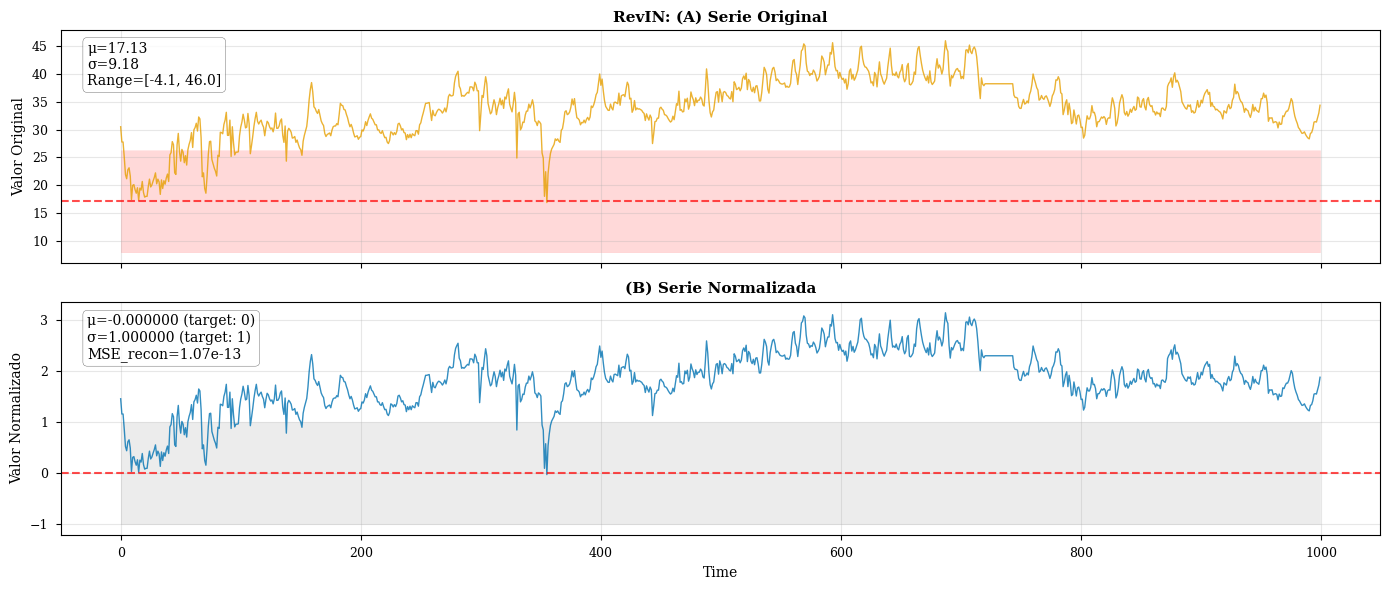


[GUARDADO] fase1_revin.pdf + .png


In [3]:
revin = RevINNormalizer()
normalized_data = revin.fit_transform(data_train)
data_train_norm = normalized_data['train']
stats = revin.get_statistics('train')

success, mse = revin.validate_reconstruction(data_train, data_train_norm, 'train')

print('[REVIN NORMALIZACIÓN]')
print(f'  Pre:  μ={data_train.mean():.3f}, σ={data_train.std():.3f}')
print(f'  Post: μ={data_train_norm.mean():.6f}, σ={data_train_norm.std():.6f}')
print(f'  Reversibilidad: MSE={mse:.2e}, Success={success}')

# VIZ: 2 paneles (antes/después) con stats
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
t_viz = 1000

# Panel 1: Original con estadísticas anotadas
ax1.plot(data_train[:t_viz], color=colors_oi[0], linewidth=1, alpha=0.8)
ax1.axhline(stats['mean'], color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.fill_between(range(t_viz), stats['mean']-stats['stdev'], stats['mean']+stats['stdev'], 
                alpha=0.15, color='red')
ax1.text(0.02, 0.95, f"μ={stats['mean']:.2f}\nσ={stats['stdev']:.2f}\nRange=[{data_train.min():.1f}, {data_train.max():.1f}]",
        transform=ax1.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax1.set_ylabel('Valor Original')
ax1.set_title('RevIN: (A) Serie Original', fontweight='bold')
ax1.grid(alpha=0.3)

# Panel 2: Normalizada con validación
ax2.plot(data_train_norm[:t_viz], color=colors_oi[4], linewidth=1, alpha=0.8)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.fill_between(range(t_viz), -1, 1, alpha=0.15, color='gray')
ax2.text(0.02, 0.95, f"μ={data_train_norm.mean():.6f} (target: 0)\nσ={data_train_norm.std():.6f} (target: 1)\nMSE_recon={mse:.2e}",
        transform=ax2.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.set_ylabel('Valor Normalizado')
ax2.set_xlabel('Time')
ax2.set_title('(B) Serie Normalizada', fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/fase1_revin.png', dpi=300)
plt.show()
print('\n[GUARDADO] fase1_revin.pdf + .png')

## 3. Baum-Welch Training

[BAUM-WELCH TRAINING]
  K=5 tokens (vocabulario)
  T=8640 timesteps
  Entrenando HMM desde cero (max_iter=200)...


Baum-Welch EM:  80%|████████  | 160/200 [18:32<04:38,  6.95s/it, LL=-886.55, ΔLL=9.54e-05]



Convergió en iteración 161/200
  Log-likelihood final: -886.5550

  Convergió: True
  Iteraciones: 161
  Log-likelihood: -886.55
  ✓ HMM guardado en cache/hmm_etth1_K5.pth


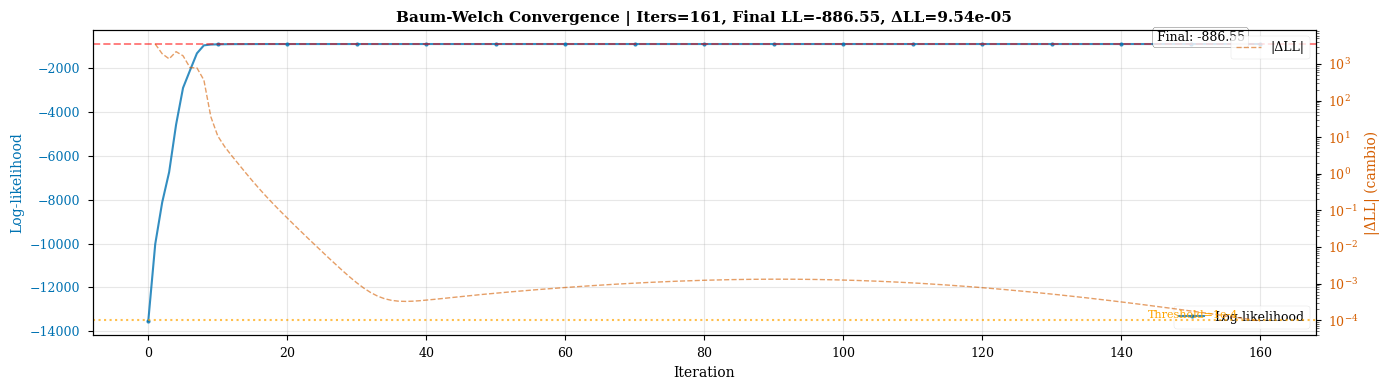

[GUARDADO] fase2_baum_welch.pdf + .png


In [4]:
K = 5
cache_path = Path('cache/hmm_etth1_K5.pth')
cache_path.parent.mkdir(exist_ok=True)

print('[BAUM-WELCH TRAINING]')
print(f'  K={K} tokens (vocabulario)')
print(f'  T={len(data_train_norm)} timesteps')

if cache_path.exists():
    print(f'  Cargando HMM desde cache...')
    hmm_params = load_hmm_params(str(cache_path))
    A = hmm_params['A']
    pi = hmm_params['pi']
    mu = hmm_params['mu']
    sigma = hmm_params['sigma']
    log_likelihoods = hmm_params.get('log_likelihoods', [])
    print(f'  ✓ HMM cargado desde cache')
else:
    print(f'  Entrenando HMM desde cero (max_iter=200)...')
    result = baum_welch(
        data_train_norm,
        K=K,
        max_iter=200,
        epsilon=1e-4,
        verbose=True
    )
    
    A = result['A']
    pi = result['pi']
    mu = result['mu']
    sigma = result['sigma']
    log_likelihoods = result.get('log_likelihoods', [])
    
    print(f'\n  Convergió: {result["converged"]}')
    print(f'  Iteraciones: {result["n_iter"]}')
    print(f'  Log-likelihood: {result["log_likelihood"]:.2f}')
    
    save_params = {
        'A': A, 'pi': pi, 'mu': mu, 'sigma': sigma,
        'log_likelihoods': log_likelihoods,
        'K': K
    }
    save_hmm_params(save_params, str(cache_path))
    print(f'  ✓ HMM guardado en {cache_path}')

# VIZ: 1 panel con convergencia + deltas anotados
if len(log_likelihoods) > 1:
    fig, ax = plt.subplots(figsize=(14, 4))
    
    # Plot convergencia con marcadores cada 10 iters
    ax.plot(log_likelihoods, color=colors_oi[4], linewidth=1.5, marker='o', 
           markersize=3, markevery=10, alpha=0.8, label='Log-likelihood')
    
    # Anotar puntos clave
    ax.axhline(log_likelihoods[-1], color='red', linestyle='--', alpha=0.5)
    ax.text(len(log_likelihoods)*0.98, log_likelihoods[-1], 
           f'Final: {log_likelihoods[-1]:.2f}', 
           ha='right', va='bottom', fontsize=9,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Delta LL en segundo eje Y
    ax2 = ax.twinx()
    deltas = np.abs(np.diff(log_likelihoods))
    ax2.plot(range(1, len(deltas)+1), deltas, color=colors_oi[5], 
            linewidth=1, alpha=0.6, linestyle='--', label='|ΔLL|')
    ax2.axhline(1e-4, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
    ax2.text(len(deltas)*0.98, 1e-4, 'Threshold=1e-4', 
            ha='right', va='bottom', fontsize=8, color='orange')
    ax2.set_ylabel('|ΔLL| (cambio)', color=colors_oi[5])
    ax2.set_yscale('log')
    ax2.tick_params(axis='y', labelcolor=colors_oi[5])
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Log-likelihood', color=colors_oi[4])
    ax.tick_params(axis='y', labelcolor=colors_oi[4])
    ax.set_title(f'Baum-Welch Convergence | Iters={len(log_likelihoods)}, Final LL={log_likelihoods[-1]:.2f}, ΔLL={deltas[-1]:.2e}', 
                fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(loc='lower right')
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig('notebooks/fase2_baum_welch.png', dpi=300)
    plt.show()
    print('[GUARDADO] fase2_baum_welch.pdf + .png')

## 4. Viterbi Tokenización

[VITERBI TOKENIZACIÓN]
  Vocabulario: K=5 tokens
  Secuencia: T=8640 tokens (1 por timestep)
  Segmentos: 318 (run-length)
  Ratio compresión: 27.17x
  Log-probabilidad: -1154.40

  Distribución tokens:
    Token 0: 1836 (21.25%)
    Token 1: 1564 (18.10%)
    Token 2: 1855 (21.47%)
    Token 3: 1683 (19.48%)
    Token 4: 1702 (19.70%)


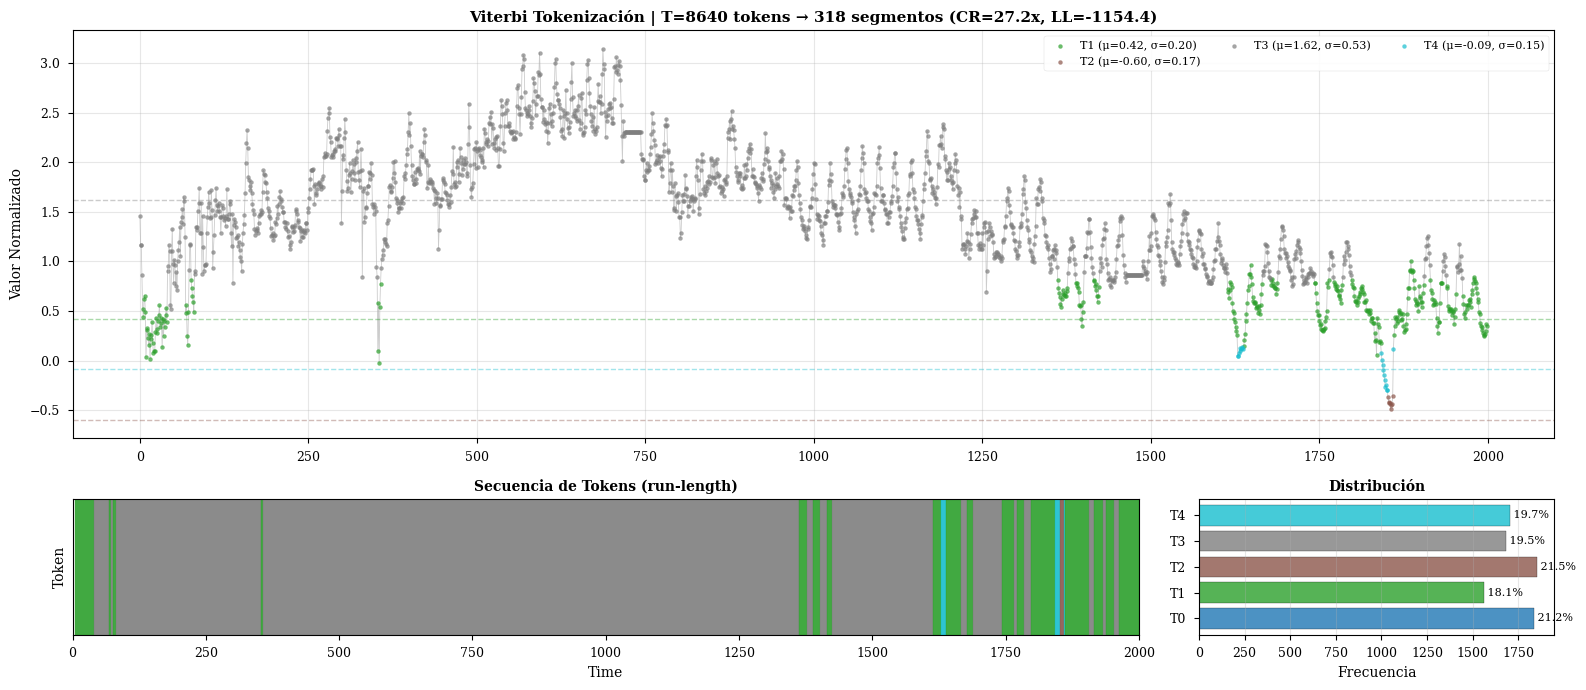


[GUARDADO] fase3_viterbi.pdf + .png


In [5]:
states, log_prob = viterbi_decode(data_train_norm, A, pi, mu, sigma)

state_changes = np.sum(states[1:] != states[:-1])
compression_ratio = len(data_train_norm) / (state_changes + 1)

print('[VITERBI TOKENIZACIÓN]')
print(f'  Vocabulario: K={K} tokens')
print(f'  Secuencia: T={len(states)} tokens (1 por timestep)')
print(f'  Segmentos: {state_changes+1} (run-length)')
print(f'  Ratio compresión: {compression_ratio:.2f}x')
print(f'  Log-probabilidad: {log_prob:.2f}')
print(f'\n  Distribución tokens:')
for k in range(K):
    count = np.sum(states == k)
    pct = 100 * count / len(states)
    print(f'    Token {k}: {count:4d} ({pct:5.2f}%)')

# VIZ: 2 paneles (serie coloreada + stats)
fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[3, 1], width_ratios=[3, 1])

ax_series = fig.add_subplot(gs[0, :])
ax_bar = fig.add_subplot(gs[1, 0])
ax_stats = fig.add_subplot(gs[1, 1])

t_viz = 2000
colors_tokens = plt.cm.tab10(np.linspace(0, 1, K))

# Panel A: Serie con tokens coloreados + medias anotadas
ax_series.plot(data_train_norm[:t_viz], color='gray', linewidth=0.6, alpha=0.4, zorder=1)
for k in range(K):
    mask = states[:t_viz] == k
    if np.any(mask):
        ax_series.scatter(np.where(mask)[0], data_train_norm[:t_viz][mask],
                         color=colors_tokens[k], s=8, alpha=0.7, 
                         label=f'T{k} (μ={mu[k]:.2f}, σ={sigma[k]:.2f})', zorder=2)
        ax_series.axhline(mu[k], color=colors_tokens[k], linestyle='--', linewidth=1, alpha=0.4)

ax_series.set_ylabel('Valor Normalizado')
ax_series.set_title(f'Viterbi Tokenización | T={len(states)} tokens → {state_changes+1} segmentos (CR={compression_ratio:.1f}x, LL={log_prob:.1f})', 
                   fontweight='bold')
ax_series.legend(loc='upper right', fontsize=8, ncol=3, framealpha=0.9)
ax_series.grid(alpha=0.3)

# Panel B: Barra de estados compacta
segment_starts = np.where(np.diff(np.concatenate([[states[0]], states[:t_viz]])) != 0)[0]
segment_starts = np.concatenate([segment_starts, [t_viz]])
for i in range(len(segment_starts)-1):
    start = segment_starts[i]
    end = segment_starts[i+1]
    token = states[start]
    ax_bar.axvspan(start, end, color=colors_tokens[token], alpha=0.9)

ax_bar.set_xlim(0, t_viz)
ax_bar.set_yticks([])
ax_bar.set_xlabel('Time')
ax_bar.set_ylabel('Token')
ax_bar.set_title('Secuencia de Tokens (run-length)', fontweight='bold', fontsize=10)

# Panel C: Estadísticas compactas
token_counts = [np.sum(states == k) for k in range(K)]
ax_stats.barh(range(K), token_counts, color=colors_tokens, alpha=0.8, edgecolor='black')
ax_stats.set_yticks(range(K))
ax_stats.set_yticklabels([f'T{k}' for k in range(K)])
ax_stats.set_xlabel('Frecuencia')
ax_stats.set_title('Distribución', fontweight='bold', fontsize=10)
ax_stats.grid(alpha=0.3, axis='x')
for k in range(K):
    pct = 100 * token_counts[k] / len(states)
    ax_stats.text(token_counts[k], k, f' {pct:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/fase3_viterbi.png', dpi=300)
plt.show()
print('\n[GUARDADO] fase3_viterbi.pdf + .png')

## 5. Embeddings Estructurados

[EMBEDDINGS ESTRUCTURADOS]
  e_k = [μ_k, σ_k, A[k,:]]
  K=5 tokens → 5 embeddings
  Dimensión cruda: 7 = 2 + K
  d_model (proyectado): 128

  Ejemplo token 0:
    μ_0=-1.160, σ_0=0.249
    A[0,:]=[0.976 0.000 0.024 0.000 0.000]


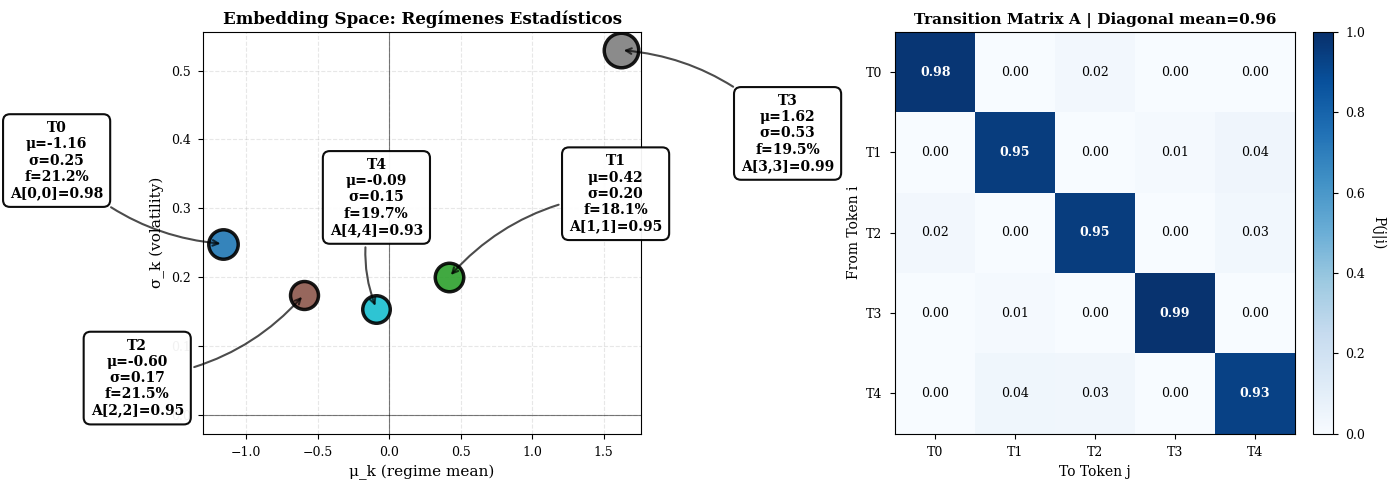


[GUARDADO] fase4_embeddings.png


In [6]:
hmm_params_dict = {'A': A, 'mu': mu, 'sigma': sigma, 'pi': pi}
emb_gen = EmbeddingGenerator(hmm_params_dict, d_model=128, device='cpu')
embedding_table = emb_gen.get_embedding_table().numpy()

print('[EMBEDDINGS ESTRUCTURADOS]')
print(f'  e_k = [μ_k, σ_k, A[k,:]]')
print(f'  K={K} tokens → {K} embeddings')
print(f'  Dimensión cruda: {embedding_table.shape[1]} = 2 + K')
print(f'  d_model (proyectado): {emb_gen.d_model}')
print(f'\n  Ejemplo token 0:')
print(f'    μ_0={mu[0]:.3f}, σ_0={sigma[0]:.3f}')
print(f'    A[0,:]=[{" ".join(f"{x:.3f}" for x in A[0,:])}]')

# VIZ: 2 paneles (espacio μ-σ + matriz A con info)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Espacio μ-σ con anotaciones detalladas y offsets
offsets = [(-120, 60), (120, 60), (-120, -60), (120, -60), (0, 80)]  # Offsets para evitar superposición

for k in range(K):
    # Scatter con tamaño proporcional a σ
    size = 300 + sigma[k] * 600  # Incrementar tamaño base
    ax1.scatter(mu[k], sigma[k], c=[colors_tokens[k]], s=size, 
               edgecolors='black', linewidths=2.5, zorder=3, alpha=0.9)
    
    # Anotación con stats usando xytext para offset
    freq_pct = 100 * np.sum(states == k) / len(states)
    persist = A[k,k]
    ax1.annotate(f'T{k}\nμ={mu[k]:.2f}\nσ={sigma[k]:.2f}\nf={freq_pct:.1f}%\nA[{k},{k}]={persist:.2f}',
                xy=(mu[k], sigma[k]), 
                xytext=offsets[k],
                textcoords='offset points',
                fontsize=10, ha='center', va='center',
                color='black', fontweight='bold', zorder=5,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                         edgecolor='black', alpha=0.95, linewidth=1.5),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2',
                              color='black', lw=1.5, alpha=0.7))

ax1.set_xlabel('μ_k (regime mean)', fontsize=11)
ax1.set_ylabel('σ_k (volatility)', fontsize=11)
ax1.set_title('Embedding Space: Regímenes Estadísticos', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3, linestyle='--')
ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax1.axvline(0, color='black', linewidth=0.8, alpha=0.5)

# Panel B: Matriz A con valores anotados
im = ax2.imshow(A, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax2.set_xlabel('To Token j')
ax2.set_ylabel('From Token i')
ax2.set_title(f'Transition Matrix A | Diagonal mean={np.diag(A).mean():.2f}', fontweight='bold')
ax2.set_xticks(range(K))
ax2.set_yticks(range(K))
ax2.set_xticklabels([f'T{k}' for k in range(K)])
ax2.set_yticklabels([f'T{k}' for k in range(K)])

# Anotar valores
for i in range(K):
    for j in range(K):
        text_color = 'white' if A[i,j] > 0.5 else 'black'
        ax2.text(j, i, f'{A[i,j]:.2f}', ha='center', va='center',
                color=text_color, fontsize=9, fontweight='bold' if i==j else 'normal')

cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('P(j|i)', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('notebooks/fase4_embeddings.png', dpi=300)
plt.show()
print('\n[GUARDADO] fase4_embeddings.png')